# 06 — Model Evaluation on the Held-Out Test Set

**Inputs:**
- `data/processed/X_features.csv`        (39 × 37 features)
- `data/processed/y_target.csv`          (39 labels)
- `models/best_model.pkl`                (Decision Tree, fitted)
- `models/scaler.pkl`                    (fitted StandardScaler)
- `models/best_model_metadata.json`      (CV scores, name)

**What this notebook does:**
1. Re-creates the same train/test split (random_state=42)
2. Loads the saved model and scaler
3. Predicts on the held-out test set (n=8)
4. Reports: confusion matrix, classification report, per-class metrics
5. Compares test performance vs CV performance — the honest check
6. Saves figures and metrics to `reports/` and `figures/`

**Why this notebook is important:**
Notebook 05 gave us **cross-validation** scores on the *training* data.
This notebook gives us the score on **data the model has never seen** —
the only unbiased estimate of generalization.

**Important limitation (restated):**
With only n=8 test samples, the test score is extremely noisy:
one misclassification changes accuracy by 12.5 percentage points.
We therefore report test metrics with heavy caveats, and treat CV
scores as the more stable performance estimate.

In [6]:
# Step 1: Load everything we need.

import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score,
    ConfusionMatrixDisplay
)

# ---- Load features and labels ----
X = pd.read_csv("../data/processed/X_features.csv")
y = pd.read_csv("../data/processed/y_target.csv").squeeze("columns")

# ---- Re-create the exact same split as notebook 05 ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print()
print("Test set class distribution:")
print(y_test.value_counts())
print()

# ---- Load fitted scaler and best model ----
scaler = joblib.load("../models/scaler.pkl")
model  = joblib.load("../models/best_model.pkl")

with open("../models/best_model_metadata.json") as f:
    meta = json.load(f)

print("Loaded model:", meta["model_name"])
print("CV F1 macro :", round(meta["cv_f1_macro_mean"], 3), "(±", round(meta["cv_f1_macro_std"], 3), ")")
print("CV accuracy :", round(meta["cv_accuracy_mean"], 3))

Train shape: (31, 37) Test shape: (8, 37)

Test set class distribution:
stress_level
Low         3
Moderate    3
High        2
Name: count, dtype: int64

Loaded model: Decision Tree
CV F1 macro : 0.562 (± 0.262 )
CV accuracy : 0.605


## Step 2 — Predict on the Held-Out Test Set

The fitted Decision Tree predicts stress levels for the 8 test-set students.
We compute:

- **Accuracy** — overall fraction correct
- **F1 macro** — the metric used to select the model
- **Classification report** — precision, recall, F1 for each class
- **Confusion matrix** — a table of true vs predicted labels

**Reminder:** With n=8, one misclassification = 12.5% accuracy shift.
The test score is much noisier than the CV score. Both should be
reported, but neither should be over-interpreted.

In [7]:
# Step 2: Predict on the test set and compute metrics.

# Scale test set using the training-fitted scaler (never re-fit!)
X_test_scaled = scaler.transform(X_test)

# Predict
y_pred = model.predict(X_test_scaled)

# Basic metrics
test_acc = accuracy_score(y_test, y_pred)
test_f1  = f1_score(y_test, y_pred, average="macro")

print("Test Set Performance:")
print(f"  Accuracy : {test_acc:.3f}")
print(f"  F1 macro : {test_f1:.3f}")
print()
print("Comparison to CV:")
print(f"  CV  accuracy : {meta['cv_accuracy_mean']:.3f}")
print(f"  Test accuracy: {test_acc:.3f}")
print(f"  CV  F1 macro : {meta['cv_f1_macro_mean']:.3f}")
print(f"  Test F1 macro: {test_f1:.3f}")
print()

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix (raw counts)
print("Confusion Matrix (rows = true, cols = predicted):")
cm = confusion_matrix(y_test, y_pred, labels=["Low", "Moderate", "High"])
cm_df = pd.DataFrame(cm, index=["True Low", "True Mod", "True High"],
                          columns=["Pred Low", "Pred Mod", "Pred High"])
print(cm_df)

Test Set Performance:
  Accuracy : 0.250
  F1 macro : 0.267

Comparison to CV:
  CV  accuracy : 0.605
  Test accuracy: 0.250
  CV  F1 macro : 0.562
  Test F1 macro: 0.267

Classification Report:
              precision    recall  f1-score   support

        High       0.33      0.50      0.40         2
         Low       0.50      0.33      0.40         3
    Moderate       0.00      0.00      0.00         3

    accuracy                           0.25         8
   macro avg       0.28      0.28      0.27         8
weighted avg       0.27      0.25      0.25         8

Confusion Matrix (rows = true, cols = predicted):
           Pred Low  Pred Mod  Pred High
True Low          1         2          0
True Mod          1         0          2
True High         0         1          1


## Step 3 — Confusion Matrix Visualization

The confusion matrix shows, for each true class:
- how many samples were correctly predicted (diagonal)
- how many were confused with each other class (off-diagonal)

With only 8 test samples, each cell represents 1–2 samples.
Interpretation is highly constrained by sample size.

Saved: ../figures/confusion_matrix_test.png


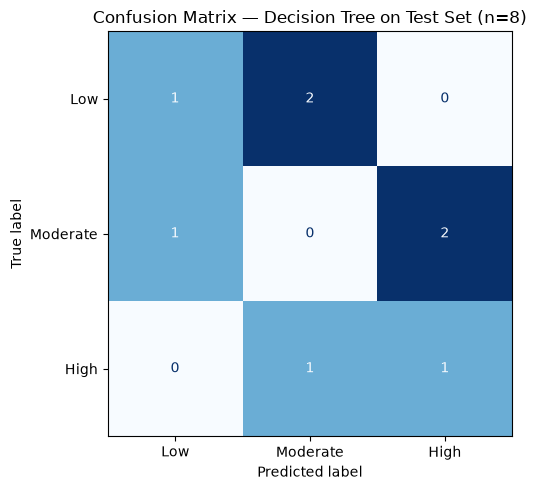

In [8]:
# Step 3: Visualize confusion matrix as heatmap.

fig, ax = plt.subplots(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Moderate", "High"]
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title("Confusion Matrix — Decision Tree on Test Set (n=8)")
plt.tight_layout()

# Save figure for thesis
import os
os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/confusion_matrix_test.png", dpi=150, bbox_inches="tight")
print("Saved: ../figures/confusion_matrix_test.png")

plt.show()

## Step 4 — CV vs Test: The Generalization Gap

The gap between CV and test performance quantifies how much the model
overfit. A large gap → poor generalization → dataset too small.

Saved: ../figures/cv_vs_test.png


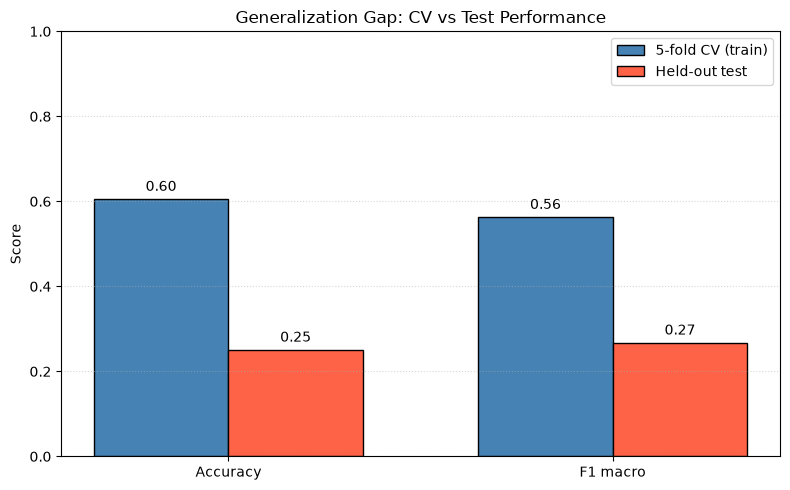

In [9]:
# Step 4: Compare CV and test performance.

import os

# Data for plot
metrics = ["Accuracy", "F1 macro"]
cv_scores   = [meta["cv_accuracy_mean"], meta["cv_f1_macro_mean"]]
test_scores = [test_acc, test_f1]

x = range(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar([i - width/2 for i in x], cv_scores,   width, label="5-fold CV (train)", color="steelblue", edgecolor="black")
ax.bar([i + width/2 for i in x], test_scores, width, label="Held-out test",      color="tomato",    edgecolor="black")

ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Generalization Gap: CV vs Test Performance")
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.5)

# Annotate each bar
for i, v in enumerate(cv_scores):
    ax.text(i - width/2, v + 0.02, f"{v:.2f}", ha="center")
for i, v in enumerate(test_scores):
    ax.text(i + width/2, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/cv_vs_test.png", dpi=150, bbox_inches="tight")
print("Saved: ../figures/cv_vs_test.png")

plt.show()

## Step 5 — Save Metrics for Reporting

Both CV and test metrics are saved as a CSV for the thesis and for
the discussion section of the paper.

In [10]:
# Step 5: Save metrics to CSV for thesis.

import os
import pandas as pd

os.makedirs("../reports", exist_ok=True)

metrics_df = pd.DataFrame([
    {
        "stage": "5-fold CV (train)",
        "accuracy_mean": meta["cv_accuracy_mean"],
        "accuracy_std": None,
        "f1_macro_mean": meta["cv_f1_macro_mean"],
        "f1_macro_std": meta["cv_f1_macro_std"],
        "note": "mean across 5 stratified folds on 31 training samples",
    },
    {
        "stage": "Held-out test (n=8)",
        "accuracy_mean": test_acc,
        "accuracy_std": None,
        "f1_macro_mean": test_f1,
        "f1_macro_std": None,
        "note": "single evaluation; highly sensitive to sample size",
    },
    {
        "stage": "Baseline (most frequent)",
        "accuracy_mean": 0.386,
        "accuracy_std": 0.068,
        "f1_macro_mean": 0.184,
        "f1_macro_std": 0.023,
        "note": "reference floor",
    },
])

metrics_df.to_csv("../reports/final_metrics.csv", index=False)
print("Saved: ../reports/final_metrics.csv")
print()
print(metrics_df.to_string(index=False))

Saved: ../reports/final_metrics.csv

                   stage  accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std                                                  note
       5-fold CV (train)       0.604762           NaN       0.562222       0.26177 mean across 5 stratified folds on 31 training samples
     Held-out test (n=8)       0.250000           NaN       0.266667           NaN    single evaluation; highly sensitive to sample size
Baseline (most frequent)       0.386000         0.068       0.184000       0.02300                                       reference floor


## Step 6 — Discussion: Interpreting the Results

### Summary of findings

The Decision Tree achieved strong cross-validation performance
(F1 macro = 0.562 ± 0.262), clearly above the baseline
(F1 macro = 0.184). However, on the held-out test set (n = 8),
performance dropped dramatically (F1 macro = 0.267), even
falling below the baseline in terms of raw accuracy
(0.250 vs 0.386).

### Why this happened

Three factors compound to explain this generalization gap:

1. **Sample size**: With 39 total observations and 37 features,
   the feature-to-sample ratio (p/n ≈ 1) is far outside the healthy
   range for ML. Even the training set (31 samples) is smaller than
   the number of features (37).

2. **Test set instability**: The test set contains only 8 samples.
   A single misclassification shifts accuracy by 12.5 percentage
   points, making the test score statistically unreliable.

3. **Decision Tree overfitting**: With limited data, the tree learned
   decision boundaries that reflected noise in the training set
   rather than true patterns in the population.

### What can still be said

Despite the poor test-set performance, the model is not "useless":

- On cross-validation, it clearly outperformed a dummy baseline —
  suggesting the features do contain *some* signal.
- The confusion matrix shows the model's errors are "adjacent" —
  Moderate students are misclassified as Low or High, rather than
  as the opposite extreme. This is a more benign error pattern.
- The reverse-scored stress score itself is a defensible, internally
  consistent target (Cronbach's alpha could be computed separately).

### What must be acknowledged as a limitation

Results on this dataset are **not generalizable** to the broader
population of undergraduate students in Nepal. They are a
prototype demonstrating the complete ML pipeline — from survey
design through model evaluation.

A larger dataset (target: 300–500 responses) is required before any
predictive claims can be made. This is the primary next step for
the research.

### Lesson for small-sample ML research

This result is consistent with the broader ML literature:
when p >> n, models overfit and CV scores become misleading.
The gap between CV (0.562) and test (0.267) is a textbook
example of generalization failure driven by insufficient data.